In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
# Load the dataset
df = pd.read_csv('../data/Raw/RawEthSmartContracts-10K-Sample.csv')

# View the data
print(df.head())
print(df.info())

                                      address  \
0  0x4e22c6177b9854ce9a87333e78a7322fc3a66e14   
1  0x7776a306b47b78a462b03cec4883685d8f9b7699   
2  0x81f2cc26dc997588cdb9ce6fc254587385d0478c   
3  0x084d277ba0fcecfb7d2105e10a3f90a7751ba949   
4  0x515661d52b238b3769f7304c425c93bc8fb807c7   

                                            bytecode  block_number  
0  0x608060405234801561001057600080fd5b5060043610...      10001419  
1  0x608060405234801561001057600080fd5b5060043610...      10001934  
2  0x608060405234801561001057600080fd5b5060043610...      10002724  
3  0x608060405234801561001057600080fd5b5060043610...      10001958  
4  0x608060405234801561001057600080fd5b5060043610...      10001963  
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   address       10000 non-null  str  
 1   bytecode      10000 non-null  str  
 2   block_number  10000 non-nu

In [8]:
# Data Preprocessing
# Extract features from bytecode
df['bytecode_length'] = df['bytecode'].apply(len)
df['bytecode_bytes'] = df['bytecode'].apply(lambda x: bytes.fromhex(x[2:]) if x.startswith('0x') else bytes.fromhex(x))
df['bytecode_size'] = df['bytecode_bytes'].apply(len)

# Simple features: count of certain opcodes (e.g., PUSH1, CALL)
def count_opcodes(bytecode):
    # Simple count of '60' (PUSH1) as example
    return bytecode.count(b'\x60')

df['push1_count'] = df['bytecode_bytes'].apply(count_opcodes)

print(df[['address', 'bytecode_length', 'bytecode_size', 'push1_count']].head())

                                      address  bytecode_length  bytecode_size  \
0  0x4e22c6177b9854ce9a87333e78a7322fc3a66e14             4608           2303   
1  0x7776a306b47b78a462b03cec4883685d8f9b7699             4608           2303   
2  0x81f2cc26dc997588cdb9ce6fc254587385d0478c             4608           2303   
3  0x084d277ba0fcecfb7d2105e10a3f90a7751ba949             4608           2303   
4  0x515661d52b238b3769f7304c425c93bc8fb807c7             4608           2303   

   push1_count  
0          288  
1          288  
2          288  
3          288  
4          288  


In [9]:
# Feature Normalization
from sklearn.preprocessing import StandardScaler

features = ['bytecode_length', 'bytecode_size', 'push1_count']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features shape:", X_scaled.shape)
print("First 5 scaled samples:")
print(X_scaled[:5])

Scaled features shape: (10000, 3)
First 5 scaled samples:
[[1.26021031 1.26021031 1.61978881]
 [1.26021031 1.26021031 1.61978881]
 [1.26021031 1.26021031 1.61978881]
 [1.26021031 1.26021031 1.61978881]
 [1.26021031 1.26021031 1.61978881]]


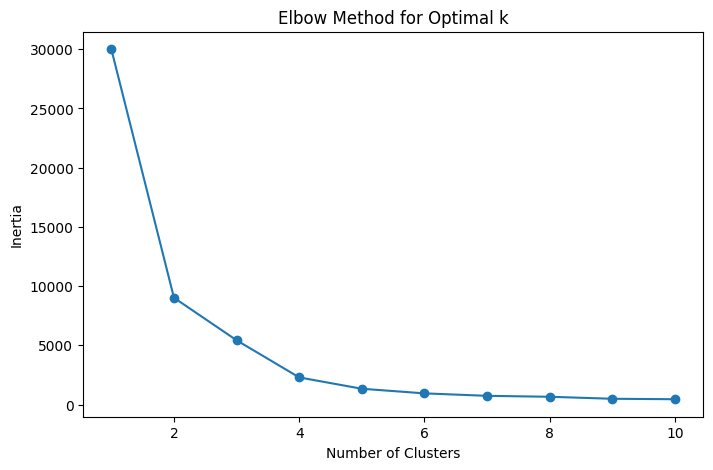

Cluster centers:
[[-0.10162528 -0.10162528 -0.09474952]
 [11.7907195  11.7907195  12.22541888]
 [ 4.83918432  4.83918432  4.03953363]]

Cluster distribution:
cluster
0    9852
2     107
1      41
Name: count, dtype: int64


In [10]:
# K-Means Clustering
# Determine optimal number of clusters using elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Choose k=3 for example
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster centers:")
print(kmeans.cluster_centers_)
print("\nCluster distribution:")
print(df['cluster'].value_counts())

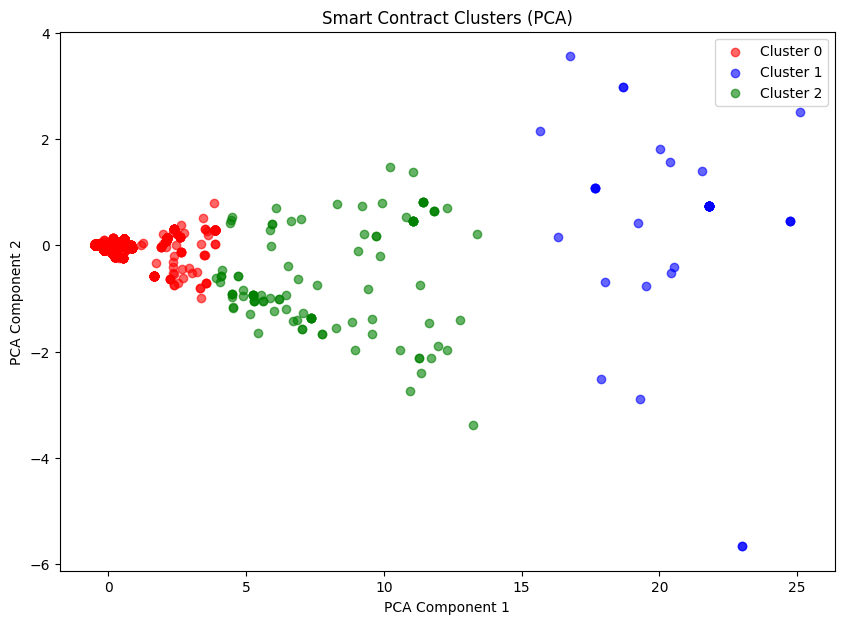

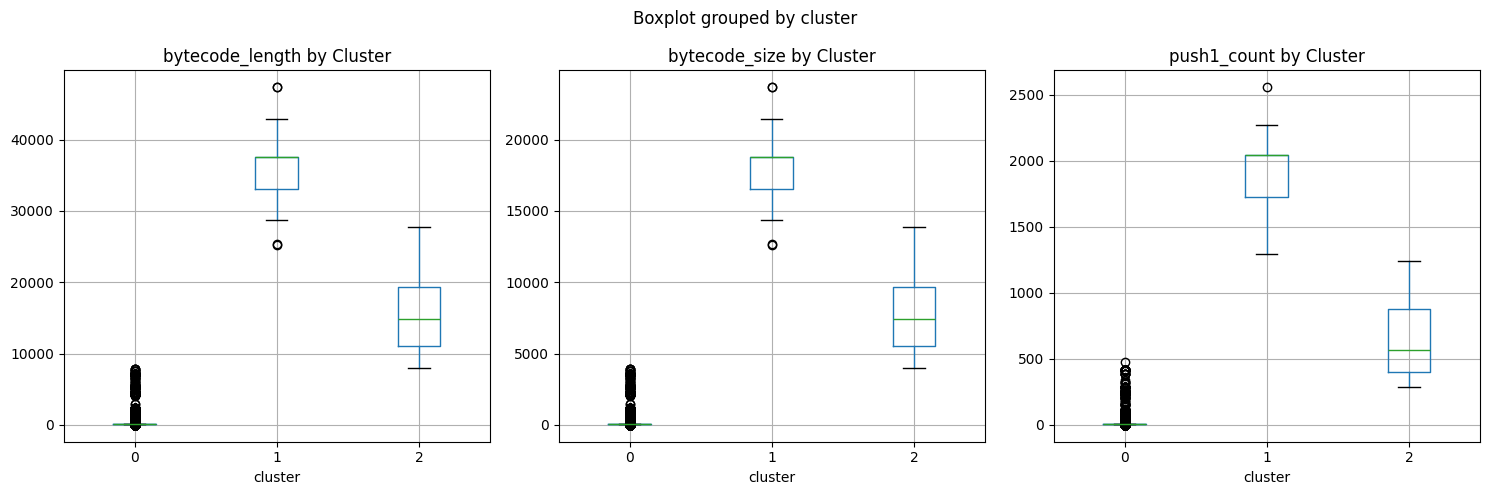

In [11]:
# Visualization of Clusters
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green']
for i in range(k_optimal):
    plt.scatter(X_pca[df['cluster'] == i, 0], X_pca[df['cluster'] == i, 1], 
                color=colors[i], label=f'Cluster {i}', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Smart Contract Clusters (PCA)')
plt.legend()
plt.show()

# Boxplot of features by cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(features):
    df.boxplot(column=feature, by='cluster', ax=axes[i])
    axes[i].set_title(f'{feature} by Cluster')
plt.tight_layout()
plt.show()

In [12]:
# Cluster Analysis
print("Summary statistics by cluster:")
for cluster in range(k_optimal):
    print(f"\nCluster {cluster}:")
    print(df[df['cluster'] == cluster][features].describe())

# Clean the dataframe for saving - keep only relevant columns
clean_df = df[['address', 'cluster'] + features]  # Keep address, cluster, and clustering features

# Ensure output directory exists
import os
os.makedirs('../data/Cleaned', exist_ok=True)

# Save cleaned clustered data
clean_df.to_csv('../data/Cleaned/clustered_contracts.csv', index=False)
print("\nCleaned clustered data saved to '../data/Cleaned/clustered_contracts.csv'")
print("Columns saved:", list(clean_df.columns))
print("Shape:", clean_df.shape)

Summary statistics by cluster:

Cluster 0:
       bytecode_length  bytecode_size  push1_count
count      9852.000000    9852.000000  9852.000000
mean        557.040195     277.520097    25.699756
std        1083.415207     541.707604    60.245033
min           2.000000       0.000000     0.000000
25%         136.000000      67.000000     3.000000
50%         136.000000      67.000000     3.000000
75%         136.000000      67.000000     3.000000
max        7844.000000    3921.000000   478.000000

Cluster 1:
       bytecode_length  bytecode_size  push1_count
count        41.000000      41.000000    41.000000
mean      35932.390244   17965.195122  1910.512195
std        5017.892331    2508.946165   279.410909
min       25252.000000   12625.000000  1296.000000
25%       33122.000000   16560.000000  1726.000000
50%       37502.000000   18750.000000  2047.000000
75%       37502.000000   18750.000000  2047.000000
max       47332.000000   23665.000000  2558.000000

Cluster 2:
       bytecode